# Ablation V2 — PSG Only (no CAD)
PromptSpatialGate ở encoder, decoder U-Net thường (không dùng PromptAttention).

In [1]:
import os, sys, subprocess
import gdown

BASE = '/kaggle/working'
os.chdir(BASE)

REPO = 'https://github.com/ThongLuc2k3/Prompt-Guided-XRay-Segmentation.git'
if not os.path.exists(f'{BASE}/pga-repo'):
    !git clone -q -b TN_B_ON {REPO} {BASE}/pga-repo
sys.path.insert(0, f'{BASE}/pga-repo')

DS_PATH = f'{BASE}/pga-repo/dataset_BTXRD'
if not os.path.exists(DS_PATH):
    gdown.download('https://drive.google.com/uc?id=1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3',
                   f'{BASE}/dataset_BTXRD.zip', quiet=False)
    !unzip -oq {BASE}/dataset_BTXRD.zip -d {BASE}/pga-repo/

os.makedirs('checkpoints', exist_ok=True)
!pip install -q tqdm opencv-python timm scipy
print("✅ Setup done")


Downloading...
From (original): https://drive.google.com/uc?id=1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3
From (redirected): https://drive.google.com/uc?id=1fU7KPln7joaa3EZZtGn-VKeg9i4AmPG3&confirm=t&uuid=fc5afb87-1f19-464e-a11a-f7b24f4889e8
To: /kaggle/working/dataset_BTXRD.zip
100%|██████████| 1.50G/1.50G [00:17<00:00, 87.9MB/s]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 8.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompa

In [2]:
%%writefile /kaggle/working/pga-repo/models/networks/prompt_unet_2D.py
import torch
import torch.nn as nn
import torch.nn.functional as F


class unetConv2(nn.Module):
    def __init__(self, in_size, out_size, is_batchnorm=True):
        super().__init__()
        if is_batchnorm:
            self.conv = nn.Sequential(
                nn.Conv2d(in_size, out_size, 3, 1, 1), nn.BatchNorm2d(out_size), nn.ReLU(inplace=True),
                nn.Conv2d(out_size, out_size, 3, 1, 1), nn.BatchNorm2d(out_size), nn.ReLU(inplace=True))
        else:
            self.conv = nn.Sequential(
                nn.Conv2d(in_size, out_size, 3, 1, 1), nn.ReLU(inplace=True),
                nn.Conv2d(out_size, out_size, 3, 1, 1), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)


class PromptSpatialGate(nn.Module):
    def __init__(self, feature_channels):
        super().__init__()
        self.gate_conv = nn.Sequential(nn.Conv2d(1, feature_channels, 1, bias=True), nn.Sigmoid())
        self.alpha = nn.Parameter(torch.tensor(0.1))
    def forward(self, features, prompt):
        if prompt.shape[2:] != features.shape[2:]:
            prompt = F.interpolate(prompt, size=features.shape[2:], mode='bilinear', align_corners=False)
        return features * (1.0 + torch.clamp(self.alpha, 0.0, 1.0) * self.gate_conv(prompt))


class unetUp_Standard(nn.Module):
    def __init__(self, skip_ch, gate_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(gate_ch, skip_ch, kernel_size=4, stride=2, padding=1)
        self.conv = unetConv2(skip_ch * 2, out_ch)
    def forward(self, skip, gating):
        u = self.up(gating)
        dy, dx = u.size(2)-skip.size(2), u.size(3)-skip.size(3)
        skip = F.pad(skip, [dx//2, dx-dx//2, dy//2, dy-dy//2])
        return self.conv(torch.cat([skip, u], dim=1))


class PGA_UNet(nn.Module):
    """V2: PSG in encoder only — standard decoder (no conditioned attention)."""
    def __init__(self, feature_scale=4, n_classes=1, in_channels=1,
                 is_batchnorm=True, use_encoder_prompt=True):
        super().__init__()
        F = [int(x / feature_scale) for x in [64, 128, 256, 512, 1024]]
        self.enc1 = unetConv2(1, F[0], is_batchnorm); self.enc2 = unetConv2(F[0], F[1], is_batchnorm)
        self.enc3 = unetConv2(F[1], F[2], is_batchnorm); self.enc4 = unetConv2(F[2], F[3], is_batchnorm)
        self.ctr  = unetConv2(F[3], F[4], is_batchnorm); self.pool = nn.MaxPool2d(2)
        self.pg1 = PromptSpatialGate(F[0]); self.pg2 = PromptSpatialGate(F[1])
        self.pg3 = PromptSpatialGate(F[2]); self.pg4 = PromptSpatialGate(F[3])
        self.up4 = unetUp_Standard(F[3], F[4], F[3]); self.up3 = unetUp_Standard(F[2], F[3], F[2])
        self.up2 = unetUp_Standard(F[1], F[2], F[1]); self.up1 = unetUp_Standard(F[0], F[1], F[0])
        self.final = nn.Conv2d(F[0], n_classes, 1)

    def forward(self, inputs, prompt):
        if self.training:
            r = torch.rand(1).item()
            if r < 0.15:   prompt = torch.zeros_like(prompt)
            elif r < 0.30: prompt = torch.clamp(prompt + torch.randn_like(prompt)*0.1, 0, 1)
        c1 = self.pg1(self.enc1(inputs), prompt)
        c2 = self.pg2(self.enc2(self.pool(c1)), prompt)
        c3 = self.pg3(self.enc3(self.pool(c2)), prompt)
        c4 = self.pg4(self.enc4(self.pool(c3)), prompt)
        ct = self.ctr(self.pool(c4))
        return self.final(self.up1(c1, self.up2(c2, self.up3(c3, self.up4(c4, ct)))))


Overwriting /kaggle/working/pga-repo/models/networks/prompt_unet_2D.py


In [3]:
USE_ENCODER_PROMPT = True   # dummy (PSG always on in V2 class)
BINARY_PROMPT      = False  # plateau heatmap input
VARIANT_NAME       = 'V2 — PSG only (no CAD)'


In [4]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, cv2, json as _json, glob, os
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt

# ── clear module cache then import model ──────────────────────────────────
import sys
sys.path.insert(0, '/kaggle/working/pga-repo')
for _k in list(sys.modules.keys()):
    if 'models' in _k or 'prompt_unet' in _k: del sys.modules[_k]
from models.networks.prompt_unet_2D import PGA_UNet

IMG_SIZE = 512
ZOOM_R   = 0.30
BATCH    = 4
EPOCHS   = 100
LR       = 1e-4
PATIENCE = 15
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class BTXRDDataset(Dataset):
    def __init__(self, split='train', mode='zoom_out'):
        self.mode = mode
        self.samples = []
        base = '/kaggle/working/pga-repo/dataset_BTXRD'
        img_dir = f'{base}/{split}/images'
        ann_dir = f'{base}/{split}/annotations'
        for jf in sorted(glob.glob(f'{ann_dir}/*.json')):
            stem = os.path.splitext(os.path.basename(jf))[0]
            img_path = next((f'{img_dir}/{stem}{e}' for e in ('.png','.jpg','.jpeg')
                             if os.path.exists(f'{img_dir}/{stem}{e}')), None)
            if not img_path: continue
            data = _json.load(open(jf, encoding='utf-8'))
            for shp in [s for s in data.get('shapes',[]) if s.get('shape_type')=='polygon']:
                pts = np.array(shp['points'], dtype=np.float32)
                self.samples.append((img_path, pts))
    def __len__(self): return len(self.samples)
    def _make_prompt(self, b):
        x1,y1,x2,y2 = int(b[0]),int(b[1]),int(b[2]),int(b[3])
        hm = np.zeros((IMG_SIZE,IMG_SIZE), dtype=np.float32)
        if x2>x1 and y2>y1:
            hm[y1:y2,x1:x2] = 1.0
            if not BINARY_PROMPT:
                hm = cv2.GaussianBlur(hm,(31,31),0)
        return hm
    def __getitem__(self, idx):
        img_path, pts = self.samples[idx]
        img_bgr = cv2.imread(img_path); H0,W0 = img_bgr.shape[:2]
        sx,sy = IMG_SIZE/W0, IMG_SIZE/H0
        pts_s = pts*np.array([sx,sy])
        img512 = cv2.resize(img_bgr,(IMG_SIZE,IMG_SIZE))
        gray = cv2.cvtColor(img512, cv2.COLOR_BGR2GRAY)
        gt = np.zeros((IMG_SIZE,IMG_SIZE), dtype=np.uint8)
        cv2.fillPoly(gt,[pts_s.astype(np.int32)],255)
        xs,ys = pts_s[:,0],pts_s[:,1]
        bw,bh = xs.max()-xs.min(), ys.max()-ys.min()
        rng = np.random.RandomState(idx + 10000)
        if self.mode == 'zoom_out' or (self.mode == 'mixed_7_3' and rng.random() < 0.7):
            b = [max(0,xs.min()-bw*ZOOM_R), max(0,ys.min()-bh*ZOOM_R),
                 min(IMG_SIZE,xs.max()+bw*ZOOM_R), min(IMG_SIZE,ys.max()+bh*ZOOM_R)]
        else:  # shift
            sx = rng.uniform(-bw*0.3, bw*0.3)
            sy = rng.uniform(-bh*0.3, bh*0.3)
            b = [max(0,xs.min()-bw*ZOOM_R+sx), max(0,ys.min()-bh*ZOOM_R+sy),
                 min(IMG_SIZE,xs.max()+bw*ZOOM_R+sx), min(IMG_SIZE,ys.max()+bh*ZOOM_R+sy)]
        hm = self._make_prompt(b)
        img_n = (gray.astype(np.float32)/255.-0.5)/0.5
        return (torch.from_numpy(img_n).unsqueeze(0).float(),
                torch.from_numpy(hm).unsqueeze(0).float(),
                torch.from_numpy(gt.astype(np.float32)/255.).unsqueeze(0).float())

def dice_loss(p, t, eps=1e-6):
    p = torch.sigmoid(p)
    i=(p*t).sum(dim=(2,3))
    return (1-(2*i+eps)/(p.sum(dim=(2,3))+t.sum(dim=(2,3))+eps)).mean()
def loss_fn(logit, t): return F.binary_cross_entropy_with_logits(logit,t)+dice_loss(logit,t)

def eval_dice(model, loader):
    model.eval(); dices=[]
    with torch.no_grad():
        for img,hm,gt in loader:
            img,hm,gt = img.to(DEVICE),hm.to(DEVICE),gt.to(DEVICE)
            p=(torch.sigmoid(model(img,hm))>0.5).float()
            i=(p*(gt>0.5)).sum(dim=(2,3)).float()
            u=p.sum(dim=(2,3))+(gt>0.5).sum(dim=(2,3)).float()
            dices+=((2*i+1e-6)/(u+1e-6)).cpu().numpy().flatten().tolist()
    return float(np.mean(dices))

# ── Build model & dataloaders ──────────────────────────────────────────────
model = PGA_UNet(in_channels=1, n_classes=1,
                 use_encoder_prompt=USE_ENCODER_PROMPT).to(DEVICE)
print(f'Model: {type(model).__name__}  params={sum(p.numel() for p in model.parameters()):,}')
print(f'BINARY_PROMPT={BINARY_PROMPT}  USE_ENCODER_PROMPT={USE_ENCODER_PROMPT}')

train_dl = DataLoader(BTXRDDataset('train'), BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(BTXRDDataset('val'),   BATCH, shuffle=False, num_workers=2)
test_dl  = DataLoader(BTXRDDataset('test'),  1,     shuffle=False, num_workers=2)

# ── Training loop ──────────────────────────────────────────────────────────
optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, factor=0.5, patience=5)

best_dice, no_imp = 0.0, 0
for ep in range(1, EPOCHS+1):
    model.train(); total=0
    for img,hm,gt in tqdm(train_dl, desc=f'Ep{ep:03d}', leave=True):
        img,hm,gt = img.to(DEVICE),hm.to(DEVICE),gt.to(DEVICE)
        loss = loss_fn(model(img,hm), gt)
        optim.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step(); total += loss.item()
    val_d = eval_dice(model, val_dl)
    sched.step(1-val_d)
    if val_d > best_dice:
        best_dice=val_d
        torch.save(model.state_dict(),'checkpoints/best.pth')
        no_imp=0
    else:
        no_imp+=1
        if no_imp>=PATIENCE: print(f'  Early stop @ ep{ep}'); break
    print(f'  ep{ep:03d}  loss={total/len(train_dl):.4f}  val_dice={val_d:.4f}  best={best_dice:.4f}')
print(f'\n✅ Training done.  Best val Dice = {best_dice:.4f}')

# ── Evaluation on test set ─────────────────────────────────────────────────
model.load_state_dict(torch.load('checkpoints/best.pth', map_location=DEVICE))
model.eval()
KEYS=['dice','iou','pre','rec','hd95','cbl']
all_results = {}

for PROMPT_MODE in ['zoom_out', 'shift', 'mixed_7_3']:
    test_dl_m = DataLoader(BTXRDDataset('test', mode=PROMPT_MODE), 1, shuffle=False, num_workers=2)
    results=[]
    with torch.no_grad():
        for img,hm,gt in tqdm(test_dl_m, f'Eval [{PROMPT_MODE}]', leave=False):
            img,hm,gt = img.to(DEVICE),hm.to(DEVICE),gt.to(DEVICE)
            prob = torch.sigmoid(model(img,hm))[0,0].cpu().numpy()
            pm=(prob>0.5).astype(np.float32); gm=gt[0,0].cpu().numpy()
            tp=(pm*gm).sum(); fp=(pm*(1-gm)).sum(); fn=((1-pm)*gm).sum(); eps=1e-6
            dice=float((2*tp+eps)/(2*tp+fp+fn+eps)); iou=float((tp+eps)/(tp+fp+fn+eps))
            pre=float((tp+eps)/(tp+fp+eps)); rec=float((tp+eps)/(tp+fn+eps))
            p,g=pm.astype(bool),gm.astype(bool); hd95=float(IMG_SIZE)
            if p.any() and g.any():
                pe=p^binary_erosion(p); ge=g^binary_erosion(g)
                d1=distance_transform_edt(~ge)[pe]; d2=distance_transform_edt(~pe)[ge]
                if len(d1) and len(d2): hd95=float(max(np.percentile(d1,95),np.percentile(d2,95)))
            cbl=0.
            if gm.sum()>0 and pm.sum()>0:
                ys_g,xs_g=np.where(gm>0.5); yp,xp=np.where(pm>0.5)
                d=np.sqrt((ys_g.max()-ys_g.min())**2+(xs_g.max()-xs_g.min())**2)+eps
                cbl=float(np.clip(1.-np.sqrt((xp.mean()-xs_g.mean())**2+(yp.mean()-ys_g.mean())**2)/d,0,1))
            results.append({'dice':dice,'iou':iou,'pre':pre,'rec':rec,'hd95':hd95,'cbl':cbl})
    m={k:np.mean([r[k] for r in results]) for k in KEYS}
    all_results[PROMPT_MODE] = m
    print(f"  [{PROMPT_MODE:12s}] Dice={m['dice']:.4f}  IoU={m['iou']:.4f}  Pre={m['pre']:.4f}  Rec={m['rec']:.4f}  HD95={m['hd95']:.2f}px  CBL={m['cbl']:.4f}")

print(f"\n{'='*70}")
print(f"  KẾT QUẢ — {VARIANT_NAME}")
print(f"{'='*70}")
for mode, m in all_results.items():
    print(f"  {mode:12s}: Dice={m['dice']:.4f}  IoU={m['iou']:.4f}  HD95={m['hd95']:.2f}px  CBL={m['cbl']:.4f}")
print(f"{'='*70}")


Model: PGA_UNet  params=2,466,485
BINARY_PROMPT=False  USE_ENCODER_PROMPT=True


Ep001: 100%|██████████| 465/465 [01:30<00:00,  5.11it/s]


  ep001  loss=1.4347  val_dice=0.1846  best=0.1846


Ep002: 100%|██████████| 465/465 [01:30<00:00,  5.13it/s]


  ep002  loss=1.2911  val_dice=0.0438  best=0.1846


...

Ep092: 100%|██████████| 465/465 [01:30<00:00,  5.12it/s]


  Early stop @ ep92

✅ Training done.  Best val Dice = 0.8765


  [zoom_out    ] Dice=0.8707  IoU=0.7791  Pre=0.8637  Rec=0.8950  HD95=14.95px  CBL=0.9610


  [shift       ] Dice=0.7285  IoU=0.5881  Pre=0.7394  Rec=0.7383  HD95=24.40px  CBL=0.8742


  [mixed_7_3   ] Dice=0.8240  IoU=0.7157  Pre=0.8243  Rec=0.8432  HD95=17.93px  CBL=0.9310

  KẾT QUẢ — V2 — PSG only (no CAD)
  zoom_out    : Dice=0.8707  IoU=0.7791  HD95=14.95px  CBL=0.9610
  shift       : Dice=0.7285  IoU=0.5881  HD95=24.40px  CBL=0.8742
  mixed_7_3   : Dice=0.8240  IoU=0.7157  HD95=17.93px  CBL=0.9310


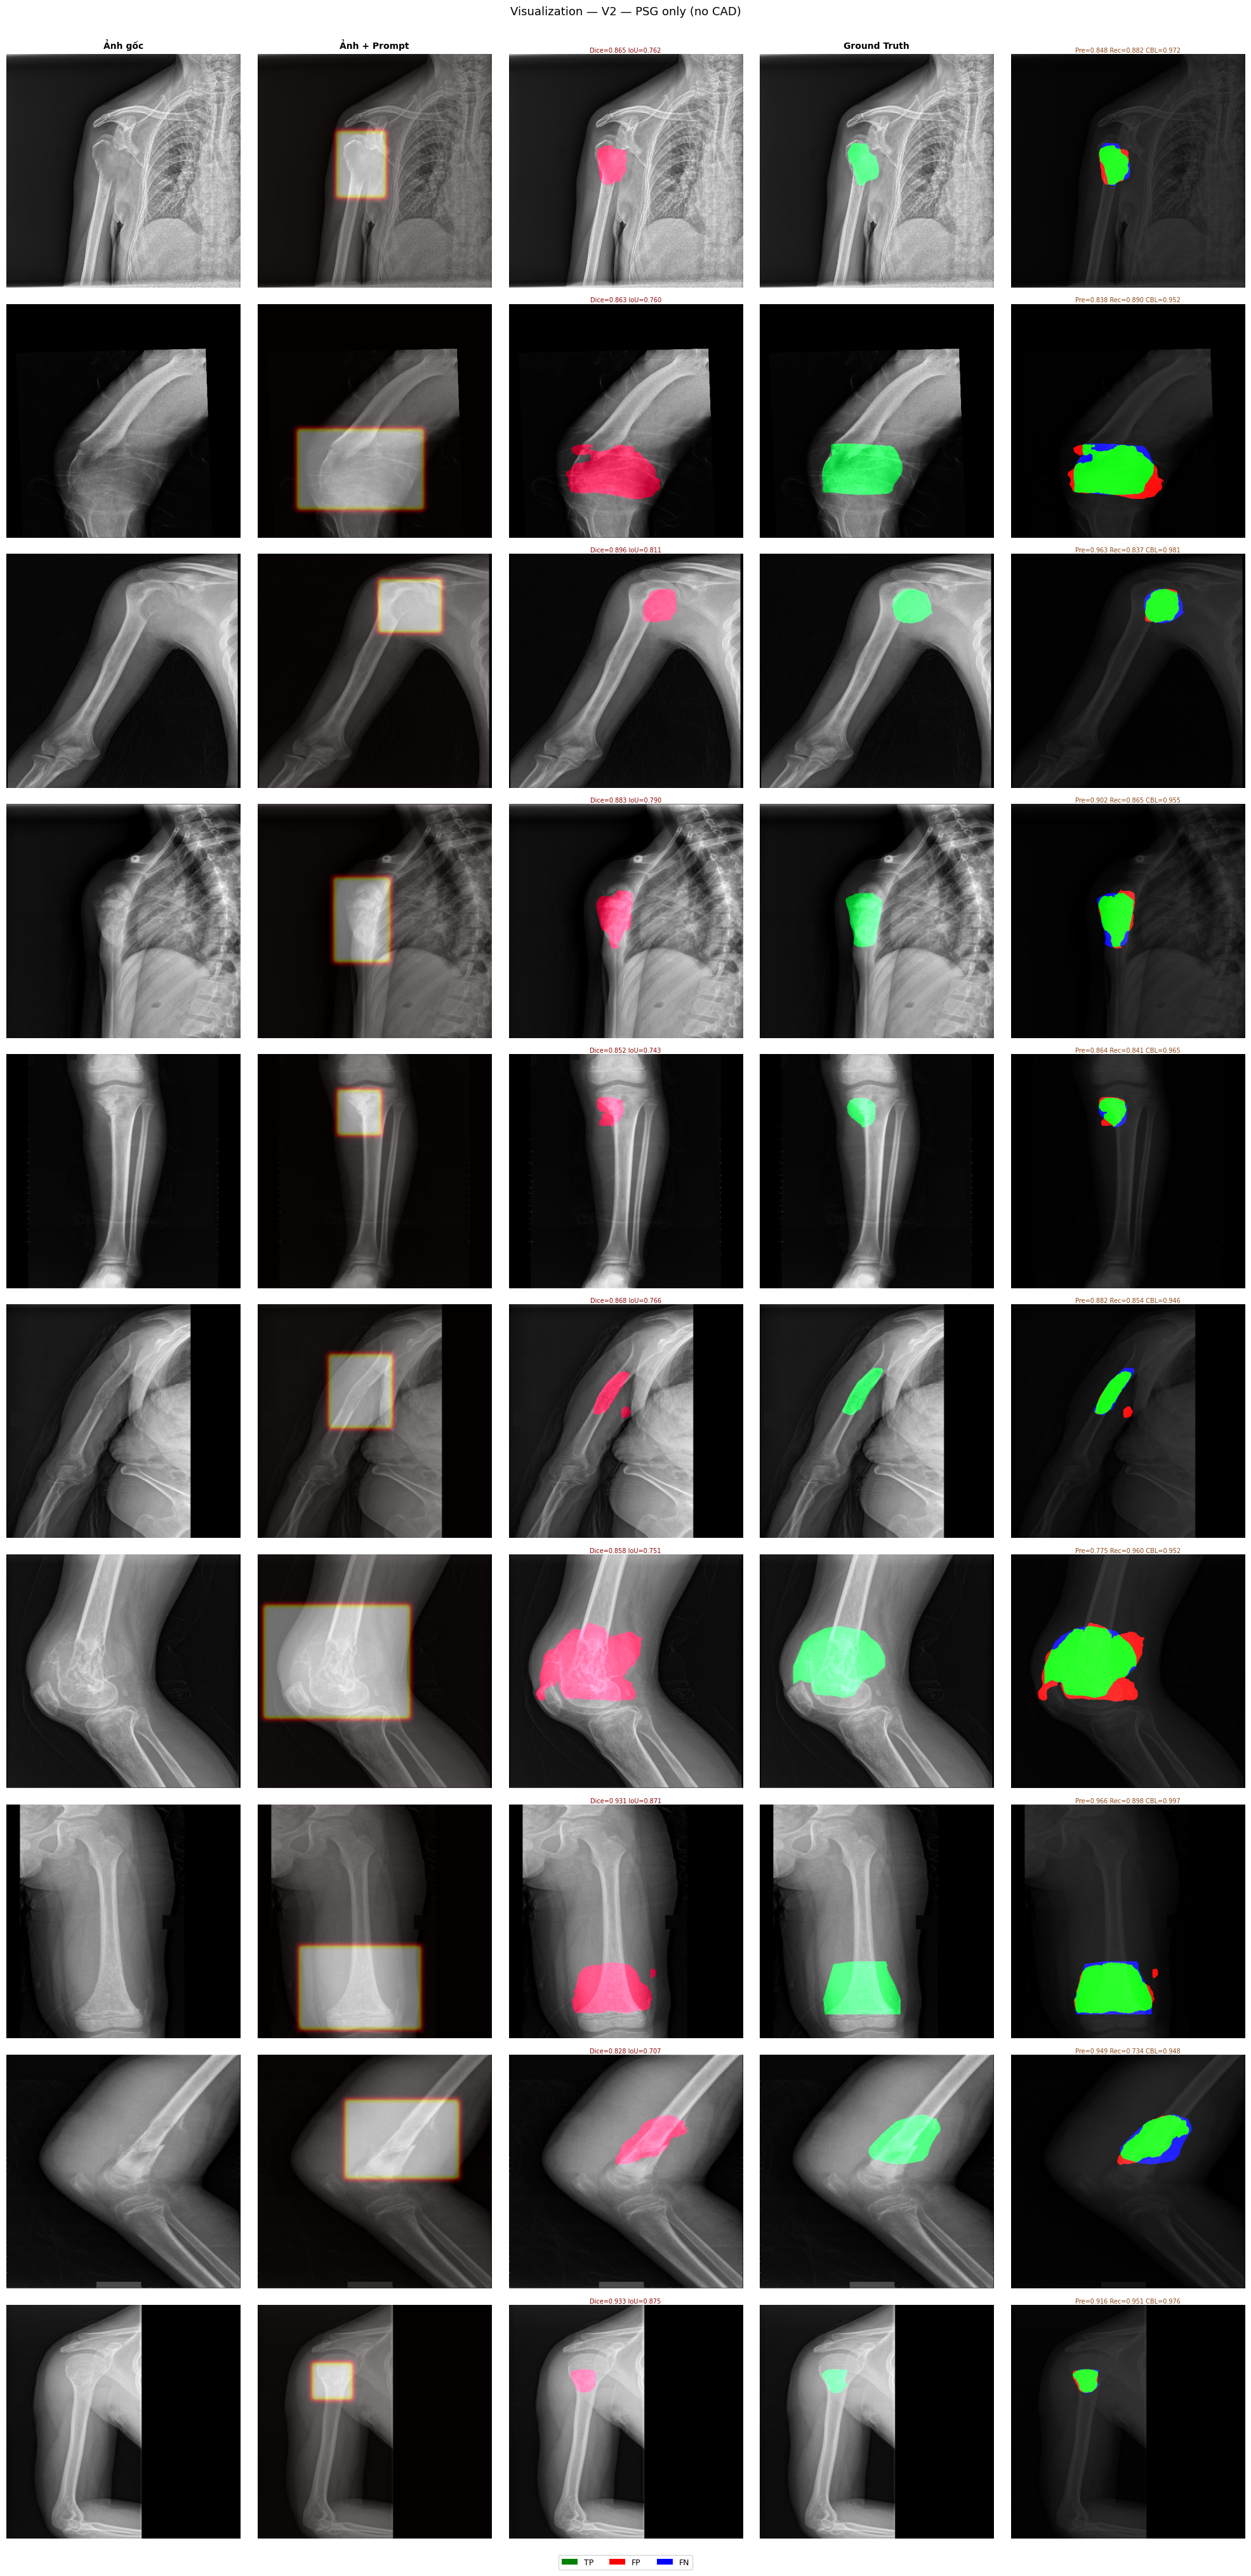

In [5]:
from IPython.display import display as _ipy_display
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion, distance_transform_edt
from matplotlib.patches import Patch

N_SHOW = 10
fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4 * N_SHOW))
fig.suptitle(f'Visualization — {VARIANT_NAME}', fontsize=13, y=1.001)
for ax, ct in zip(axes[0], ['Ảnh gốc', 'Ảnh + Prompt', 'Dự đoán', 'Ground Truth', 'TP/FP/FN']):
    ax.set_title(ct, fontsize=10, fontweight='bold')

model.eval()
count = 0
with torch.no_grad():
    for img, hm, gt in test_dl:
        if count >= N_SHOW:
            break
        img_np  = (img[0, 0].cpu().numpy() * 0.5 + 0.5)
        hm_np   = hm[0, 0].cpu().numpy()
        gt_np   = (gt[0, 0].cpu().numpy() > 0.5).astype(float)
        prob_np = torch.sigmoid(model(img.to(DEVICE), hm.to(DEVICE)))[0, 0].cpu().numpy()
        pred_np = (prob_np > 0.5).astype(float)

        tp=(pred_np*gt_np).sum(); fp=(pred_np*(1-gt_np)).sum(); fn=((1-pred_np)*gt_np).sum(); e=1e-6
        dice=float((2*tp+e)/(2*tp+fp+fn+e)); iou=float((tp+e)/(tp+fp+fn+e))
        pre=float((tp+e)/(tp+fp+e));         rec=float((tp+e)/(tp+fn+e))
        pb,gb=pred_np.astype(bool),gt_np.astype(bool); hd=float(IMG_SIZE)
        if pb.any() and gb.any():
            pe=pb^binary_erosion(pb); ge=gb^binary_erosion(gb)
            d1=distance_transform_edt(~ge)[pe]; d2=distance_transform_edt(~pe)[ge]
            if len(d1) and len(d2): hd=float(max(np.percentile(d1,95),np.percentile(d2,95)))
        cbl=0.
        if gt_np.sum()>0 and pred_np.sum()>0:
            ys,xs=np.where(gt_np>0.5); yp,xp=np.where(pred_np>0.5)
            dc=np.sqrt((ys.max()-ys.min())**2+(xs.max()-xs.min())**2)+e
            cbl=float(np.clip(1.-np.sqrt((xp.mean()-xs.mean())**2+(yp.mean()-ys.mean())**2)/dc,0,1))

        row = axes[count]
        bg  = np.stack([img_np]*3, axis=-1)

        row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        row[0].set_ylabel(f'#{count+1} Dice={dice:.3f}', fontsize=8)

        row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        row[1].imshow(hm_np,  cmap='hot',  alpha=0.4, vmin=0, vmax=1)

        pr_ov = bg.copy()
        pr_ov[...,0] = np.clip(pr_ov[...,0] + pred_np*0.55, 0, 1)
        pr_ov[...,1] = np.clip(pr_ov[...,1] - pred_np*0.2,  0, 1)
        row[2].imshow(pr_ov)
        row[2].set_title(f'Dice={dice:.3f} IoU={iou:.3f}', fontsize=7, color='darkred', pad=2)

        gt_ov = bg.copy()
        gt_ov[...,1] = np.clip(gt_ov[...,1] + gt_np*0.55, 0, 1)
        gt_ov[...,0] = np.clip(gt_ov[...,0] - gt_np*0.2,  0, 1)
        row[3].imshow(gt_ov)

        inter = bg.copy() * 0.25
        inter[...,1] = np.clip(inter[...,1] + pred_np*gt_np*0.9,     0, 1)
        inter[...,0] = np.clip(inter[...,0] + pred_np*(1-gt_np)*1.0, 0, 1)
        inter[...,2] = np.clip(inter[...,2] + (1-pred_np)*gt_np*1.0, 0, 1)
        row[4].imshow(inter)
        row[4].set_title(f'Pre={pre:.3f} Rec={rec:.3f} CBL={cbl:.3f}', fontsize=7, color='saddlebrown', pad=2)

        for ax in row:
            ax.axis('off')
        count += 1

fig.legend(handles=[Patch(facecolor='green',label='TP'),Patch(facecolor='red',label='FP'),Patch(facecolor='blue',label='FN')],
           loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5,-0.01))
plt.tight_layout()
_ipy_display(fig)
plt.close(fig)
